# 🟠 BTC Squeeze H1 — Backtest Ultra-Fidèle (Tick-by-Tick)

**Architecture** : H1 (signaux Squeeze) → Ticks (exécution chirurgicale)  
**Stratégie** : Squeeze Momentum Breakout — BB 20/2.5 × KC 20/2.0 — Filtre EMA200  
**Positions** : P1 (TP1 fixe RR 1:2) + P2 (Runner EMA20 trailing)

---

## 📁 FICHIERS REQUIS AVANT D'EXÉCUTER

Placer les fichiers suivants dans le dossier **`data/`** à côté de ce notebook :

| Fichier | Description | Format attendu |
|---|---|---|
| `BTCUSD_H1_Xmonths.csv` | Bougies H1 BTCUSD | `Time,Open,High,Low,Close,TickVolume` |
| `BTCUSD_Ticks_Xmonths.csv` | Ticks BTCUSD | `Time,Bid,Ask,Last,Volume` |

**Période recommandée** : 1 an minimum (≥ 8 000 bougies H1 / ≥ 50M ticks)  
**Export MT5** : Historique → BTCUSD H1 → Exporter CSV (même procédure pour les ticks)

**Format Time attendu** : `2024.01.01 01:00:00` (format MT5 standard)

> ⚠️ Mettre à jour les variables `PATH_H1` et `PATH_TICKS` dans la **Cellule 1** avec les vrais noms de fichiers.

In [1]:
# ================================================================
# CELLULE 1 — Configuration globale
# ================================================================
# ⚠️  SEULE SOURCE DE VÉRITÉ pour toutes les constantes.
#     Ne pas redéfinir ces variables dans les cellules suivantes.
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import time
import pickle
import multiprocessing
from datetime import timedelta
from pathlib import Path
from collections import OrderedDict
from concurrent.futures import ThreadPoolExecutor, as_completed

try:
    import polars as pl
    print(f'✅ Polars {pl.__version__} disponible')
except ImportError:
    raise ImportError('Installez polars : pip install polars')

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

# ── Chemins fichiers — ADAPTER ICI ──────────────────────────────
PATH_H1    = Path('data\BTCUSD_H1_2y_Data.csv')      # ← ton fichier H1
PATH_TICKS = Path('data\BTCUSD_Ticks_Data2y.csv')   # ← ton fichier ticks
PATH_TICKS_PARQUET = Path('data/BTCUSD_Ticks.parquet')
CACHE_FILE          = Path('data/btc_precomp_indicators.pkl')

# ── Paramètres du bot (réplique exacte btc_squeeze_h1_v2.py) ────
BB_PERIOD           = 20
BB_DEV              = 2.5
KC_PERIOD           = 20
KC_MULT             = 2.0
ATR_PERIOD          = 14
VOL_SMA_PERIOD      = 20
EMA_TRAIL_PERIOD    = 20
VOL_BREAKOUT_FACTOR = 1.5
SL_ATR_MULT         = 2.0
TP1_RR              = 2.0

# ── Paramètres de risque ────────────────────────────────────────
DAILY_MAX_LOSS      = -500.0   # coupe-circuit journalier
MAX_TRADES_PER_DAY  = 5        # max trades H1 par jour
MAX_SPREAD_USD      = 50.0     # spread max toléré en USD

# ── PnL par dollar de move (LOT_SIZE × contrat) ─────────────────
# BTCUSD : 1 lot = 1 BTC. PnL = move_usd × lot_size
LOT_SIZE            = 0.02     # lot total (P1 + P2 = 0.01 + 0.01)
LOT_P1              = 0.01
LOT_P2              = 0.01
PNL_PER_USD_P1      = LOT_P1   # PnL P1 = move_usd × 0.01
PNL_PER_USD_P2      = LOT_P2   # PnL P2 = move_usd × 0.01

# ── Friction broker BTC (slippage à l'entrée) ───────────────────
# NE PAS REDÉFINIR AILLEURS
SLIPPAGE_USD        = 15.0     # slippage entrée en USD (conservateur)

print('✅ Imports et configuration OK')
print(f'   BB={BB_PERIOD}/{BB_DEV} | KC={KC_PERIOD}/{KC_MULT} | ATR={ATR_PERIOD}')
print(f'   SL_MULT={SL_ATR_MULT}×ATR | TP1_RR=1:{TP1_RR} | VOL_FILTER={VOL_BREAKOUT_FACTOR}×SMA')
print(f'   LOT_P1={LOT_P1} | LOT_P2={LOT_P2} | SLIPPAGE={SLIPPAGE_USD}$ | DAILY_STOP={DAILY_MAX_LOSS}$')

<>:36: SyntaxWarning: invalid escape sequence '\B'
<>:37: SyntaxWarning: invalid escape sequence '\B'
<>:36: SyntaxWarning: invalid escape sequence '\B'
<>:37: SyntaxWarning: invalid escape sequence '\B'
C:\Users\AymaneELHOMAIDI\AppData\Local\Temp\ipykernel_23080\1559773648.py:36: SyntaxWarning: invalid escape sequence '\B'
  PATH_H1    = Path('data\BTCUSD_H1_2y_Data.csv')      # ← ton fichier H1
C:\Users\AymaneELHOMAIDI\AppData\Local\Temp\ipykernel_23080\1559773648.py:37: SyntaxWarning: invalid escape sequence '\B'
  PATH_TICKS = Path('data\BTCUSD_Ticks_Data2y.csv')   # ← ton fichier ticks


✅ Polars 1.40.1 disponible
✅ Imports et configuration OK
   BB=20/2.5 | KC=20/2.0 | ATR=14
   SL_MULT=2.0×ATR | TP1_RR=1:2.0 | VOL_FILTER=1.5×SMA
   LOT_P1=0.01 | LOT_P2=0.01 | SLIPPAGE=15.0$ | DAILY_STOP=-500.0$


In [2]:
# ================================================================
# CELLULE 2 — Chargement H1 (pandas)
# ================================================================

def load_h1(path: Path) -> pd.DataFrame:
    """Charge le CSV H1 broker MT5."""
    df = pd.read_csv(path, parse_dates=['Time'])
    # Renommage flexible selon le format MT5
    rename_map = {}
    for col in df.columns:
        cl = col.strip().lower()
        if cl == 'tickvolume' or cl == 'volume': rename_map[col] = 'Volume'
        elif cl == 'open':  rename_map[col] = 'Open'
        elif cl == 'high':  rename_map[col] = 'High'
        elif cl == 'low':   rename_map[col] = 'Low'
        elif cl == 'close': rename_map[col] = 'Close'
    df.rename(columns=rename_map, inplace=True)
    df.set_index('Time', inplace=True)
    df.sort_index(inplace=True)
    for c in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[c] = df[c].astype(float)
    print(f'✅ H1 chargé : {len(df):,} bougies | {df.index[0]} → {df.index[-1]}')
    return df

df_h1 = load_h1(PATH_H1)

# Détection format ticks
print('\n🔍 Détection format tick CSV...')
with open(PATH_TICKS, 'r') as f:
    for i, line in enumerate(f):
        print(f'  Ligne {i}: {line.strip()}')
        if i >= 3: break

tick_size_gb = PATH_TICKS.stat().st_size / 1e9
print(f'\n📊 Fichier ticks : {tick_size_gb:.2f} GB')
print('  → Polars LazyFrame : lecture sélective par fenêtre de trade')

✅ H1 chargé : 17,029 bougies | 2024-05-10 21:00:00 → 2026-05-10 20:00:00

🔍 Détection format tick CSV...
  Ligne 0: Time,Bid,Ask,Last,Volume
  Ligne 1: 2024.05.10 20:52:34.060,60368.08,60382.78,0.00,0
  Ligne 2: 2024.05.10 20:52:34.718,60362.64,60373.88,0.00,0
  Ligne 3: 2024.05.10 20:52:35.217,60367.96,60381.38,0.00,0

📊 Fichier ticks : 5.56 GB
  → Polars LazyFrame : lecture sélective par fenêtre de trade


In [3]:
# ================================================================
# CELLULE 2b — Conversion CSV Ticks → Parquet (UNE SEULE FOIS)
# ================================================================
# Exécuter une seule fois (~5-15 min selon disque).
# Ensuite le Parquet est réutilisé automatiquement.
# ================================================================

def convert_ticks_to_parquet():
    if PATH_TICKS_PARQUET.exists():
        size_gb = PATH_TICKS_PARQUET.stat().st_size / 1e9
        print(f'✅ Parquet déjà existant ({size_gb:.2f} GB) — conversion ignorée')
        return

    print(f'⏳ Conversion CSV → Parquet ({PATH_TICKS.stat().st_size/1e9:.1f} GB)...')
    print('  Cela prend 5-15 min selon votre disque. À faire UNE SEULE FOIS !\n')
    t0 = time.time()

    with open(PATH_TICKS, 'r') as f:
        header_line = f.readline().strip()
    raw_cols = [c.strip().strip('<>') for c in header_line.split(',')]

    time_col = next((c for c in raw_cols if 'time' in c.lower()), raw_cols[0])
    bid_col  = next((c for c in raw_cols if 'bid'  in c.lower()), None)
    ask_col  = next((c for c in raw_cols if 'ask'  in c.lower()), None)

    if bid_col is None or ask_col is None:
        raise ValueError(f'Colonnes Bid/Ask non trouvées dans : {raw_cols}')
    print(f'  Colonnes : Time="{time_col}" Bid="{bid_col}" Ask="{ask_col}"')

    (
        pl.scan_csv(PATH_TICKS, try_parse_dates=False, infer_schema_length=500)
        .select([time_col, bid_col, ask_col])
        .rename({time_col: 'RawTime', bid_col: 'Bid', ask_col: 'Ask'})
        .with_columns([
            pl.col('Bid').cast(pl.Float64),
            pl.col('Ask').cast(pl.Float64),
            pl.col('RawTime')
              .str.to_datetime(format='%Y.%m.%d %H:%M:%S%.3f', strict=False)
              .alias('Time')
        ])
        .drop('RawTime')
        .sink_parquet(PATH_TICKS_PARQUET, compression='snappy')
    )

    elapsed = time.time() - t0
    size_gb = PATH_TICKS_PARQUET.stat().st_size / 1e9
    print(f'\n✅ Parquet créé : {size_gb:.2f} GB en {elapsed:.0f}s')
    print(f'  Lectures futures ~50× plus rapides')

convert_ticks_to_parquet()
_TICKS_LAZY = pl.scan_parquet(PATH_TICKS_PARQUET)
print('\n✅ LazyFrame Parquet prêt')

✅ Parquet déjà existant (1.45 GB) — conversion ignorée

✅ LazyFrame Parquet prêt


In [4]:
# ================================================================
# CELLULE 3 — Moteur d'indicateurs (réplique exacte du bot)
# ================================================================

def _atr_series(df: pd.DataFrame, period: int) -> pd.Series:
    tr = pd.concat([
        df['High'] - df['Low'],
        (df['High'] - df['Close'].shift(1)).abs(),
        (df['Low']  - df['Close'].shift(1)).abs(),
    ], axis=1).max(axis=1)
    return tr.rolling(period).mean()


def compute_signals_backtest(df: pd.DataFrame) -> dict:
    """
    Réplique vectorisée EXACTE de compute_signals() du bot.
    Retourne un dict avec tous les signaux pour la DERNIÈRE bougie.
    """
    close = df['Close']
    vol   = df['Volume']

    # Bollinger Bands
    bb_mid = close.rolling(BB_PERIOD).mean()
    bb_std = close.rolling(BB_PERIOD).std(ddof=0)
    bb_up  = bb_mid + BB_DEV * bb_std
    bb_lo  = bb_mid - BB_DEV * bb_std

    # Keltner Channels
    atr_s  = _atr_series(df, KC_PERIOD)
    kc_mid = close.rolling(KC_PERIOD).mean()
    kc_up  = kc_mid + KC_MULT * atr_s
    kc_lo  = kc_mid - KC_MULT * atr_s

    # ATR sizing
    atr14  = _atr_series(df, ATR_PERIOD)

    # Volume SMA
    vol_sma = vol.rolling(VOL_SMA_PERIOD).mean()

    # EMAs
    ema20  = close.ewm(span=EMA_TRAIL_PERIOD, adjust=False).mean()
    ema200 = close.ewm(span=200, adjust=False).mean()

    # Squeeze
    squeeze = (bb_up < kc_up) & (bb_lo > kc_lo)

    n = len(df)
    prev_sq    = squeeze.iloc[n - 2]
    cur_sq     = squeeze.iloc[n - 1]
    cur_close  = close.iloc[n - 1]
    cur_bb_up  = bb_up.iloc[n - 1]
    cur_bb_lo  = bb_lo.iloc[n - 1]
    cur_vol    = vol.iloc[n - 1]
    cur_vsma   = vol_sma.iloc[n - 1]
    cur_atr    = atr14.iloc[n - 1]
    cur_ema20  = ema20.iloc[n - 1]
    cur_ema200 = ema200.iloc[n - 1]
    trend_bull = cur_close > cur_ema200
    trend_bear = cur_close < cur_ema200

    vol_ratio = cur_vol / cur_vsma if cur_vsma > 0 else 1.0

    breakout_long = (
        prev_sq and not cur_sq
        and cur_close > cur_bb_up
        and cur_vol > VOL_BREAKOUT_FACTOR * cur_vsma
        and trend_bull
    )
    breakout_short = (
        prev_sq and not cur_sq
        and cur_close < cur_bb_lo
        and cur_vol > VOL_BREAKOUT_FACTOR * cur_vsma
        and trend_bear
    )

    return {
        'close':          round(cur_close, 2),
        'atr':            round(cur_atr, 2),
        'ema20':          round(cur_ema20, 2),
        'ema20_series':   ema20,
        'ema200':         round(cur_ema200, 2),
        'trend_bull':     bool(trend_bull),
        'trend_bear':     bool(trend_bear),
        'vol_ratio':      round(vol_ratio, 3),
        'squeeze':        bool(cur_sq),
        'prev_squeeze':   bool(prev_sq),
        'breakout_long':  bool(breakout_long),
        'breakout_short': bool(breakout_short),
        'bb_up':          round(cur_bb_up, 2),
        'bb_lo':          round(cur_bb_lo, 2),
        'kc_up':          round(kc_up.iloc[n - 1], 2),
        'kc_lo':          round(kc_lo.iloc[n - 1], 2),
    }

print('✅ Moteur d\'indicateurs défini (réplique exacte bot v2)')

✅ Moteur d'indicateurs défini (réplique exacte bot v2)


In [5]:
# ================================================================
# CELLULE 4 — Calcul TP/SL (réplique exacte du bot)
# ================================================================

def calculate_tp_sl(direction: str, entry: float, atr: float) -> dict:
    """
    Réplique exacte de attempt_entry() du bot :
    SL = entry ± 2.0×ATR
    TP1 = entry ± 2×risk  (RR 1:2)
    P2 runner = pas de TP fixe (géré par EMA20 trail)
    """
    risk = SL_ATR_MULT * atr
    if direction == 'BUY':
        sl  = round(entry - risk, 2)
        tp1 = round(entry + TP1_RR * risk, 2)
    else:
        sl  = round(entry + risk, 2)
        tp1 = round(entry - TP1_RR * risk, 2)
    return {'sl': sl, 'tp1': tp1, 'risk': round(risk, 2)}

print('✅ Calcul TP/SL défini')
# Exemple de vérification
ex = calculate_tp_sl('BUY', 65000, 500)
print(f'   Exemple BUY @ 65000, ATR=500 → SL={ex["sl"]} TP1={ex["tp1"]} Risk={ex["risk"]}$')

✅ Calcul TP/SL défini
   Exemple BUY @ 65000, ATR=500 → SL=64000.0 TP1=67000.0 Risk=1000.0$


In [6]:
# ================================================================
# CELLULE 5 — Pré-calcul des indicateurs H1 (avec cache disque)
# ================================================================
# Calcule compute_signals_backtest() pour chaque bougie H1.
# Sauvegarde dans data/btc_precomp_indicators.pkl pour réutilisation.
# ================================================================

WINDOW = 250   # bougies H1 de lookback pour les EMAs longues (EMA200)

def precompute_all_signals(df: pd.DataFrame, window: int = WINDOW) -> OrderedDict:
    # if CACHE_FILE.exists():
    #     print('📂 Lecture du cache disque (btc_precomp_indicators.pkl)...')
    #     with open(CACHE_FILE, 'rb') as f:
    #         result = pickle.load(f)
    #     print(f'✅ Cache chargé : {len(result):,} timestamps')
    #     return result

    t0 = time.time()
    candle_times = df.index.tolist()
    total = len(df)
    precomp = OrderedDict()

    with tqdm(total=total - window, desc='Pré-calcul signaux H1', unit='bougies', ncols=80) as pbar:
        for i in range(window, total):
            ts = candle_times[i]
            try:
                sig = compute_signals_backtest(df.iloc[i - window: i + 1])
                sig['ts'] = ts
                precomp[ts] = sig
            except Exception:
                pass
            pbar.update(1)

    print(f'\nPré-calcul terminé : {len(precomp):,} timestamps en {time.time()-t0:.1f}s')
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(precomp, f)
    print('✅ Cache sauvegardé')
    return precomp

if 'precomp_signals' not in globals() or not precomp_signals:
    precomp_signals = precompute_all_signals(df_h1)
else:
    print('✅ Signaux déjà en RAM — calcul ignoré')

Pré-calcul signaux H1:   0%|                     | 0/16779 [00:00<?, ?bougies/s]


Pré-calcul terminé : 16,779 timestamps en 81.7s
✅ Cache sauvegardé


In [7]:
# ================================================================
# CELLULE 6 — Collecte des timestamps de signaux + cache ticks
# ================================================================
# CORRECTION TIME-TRAVEL : les ticks sont lus depuis ts + 1H
# (clôture de la bougie H1) et non ts (ouverture).
# ================================================================

def _fetch_ticks_numpy(signal_close_time, max_hours: int = 72):
    """
    Extrait les ticks Parquet pour la fenêtre [signal_close_time, +max_hours].
    signal_close_time = timestamp de CLÔTURE de la bougie H1 signal.
    """
    t_end = signal_close_time + timedelta(hours=max_hours)
    df = (
        _TICKS_LAZY
        .filter(
            (pl.col('Time') >= signal_close_time) &
            (pl.col('Time') <= t_end)
        )
        .select(['Bid', 'Ask'])
        .collect(streaming=True)
    )
    if df.is_empty():
        return np.array([]), np.array([])
    return df['Bid'].to_numpy(), df['Ask'].to_numpy()


def collect_signal_times(precomp: OrderedDict) -> list:
    """
    Filtre les timestamps où un breakout valide est détecté.
    Un seul trade actif à la fois (réplique logique du bot).
    """
    signal_times = []
    daily_pnl    = 0.0
    trades_today = 0
    cur_date     = None

    for ts, sig in precomp.items():
        day = ts.date()
        if day != cur_date:
            cur_date     = day
            daily_pnl    = 0.0
            trades_today = 0

        if daily_pnl < DAILY_MAX_LOSS:        continue
        if trades_today >= MAX_TRADES_PER_DAY: continue
        if not (sig['breakout_long'] or sig['breakout_short']): continue

        signal_times.append(ts)
        trades_today += 1

    return signal_times


def build_tick_cache(signal_times: list, max_hours: int = 72) -> dict:
    cache = {}
    print(f'📦 Chargement de {len(signal_times)} fenêtres de ticks...')
    t0 = time.time()
    for ts in tqdm(signal_times, desc='Cache ticks', unit='trade', ncols=70):
        # ✅ CORRECTION TIME-TRAVEL : clôture = ts + 1H (bougie H1)
        close_time = ts + timedelta(hours=1)
        bids, asks = _fetch_ticks_numpy(close_time, max_hours=max_hours)
        if len(bids) > 0:
            cache[ts] = (bids, asks)
        else:
            print(f'  ⚠️  Aucun tick trouvé pour {ts} (close_time={close_time})')
    elapsed = time.time() - t0
    total_mb = sum(b.nbytes + a.nbytes for b, a in cache.values()) / 1e6
    print(f'\n✅ Cache prêt : {len(cache)} trades | {total_mb:.1f} MB RAM | {elapsed:.0f}s')
    return cache


print('🔍 Collecte des timestamps de signaux...')
all_signal_times = collect_signal_times(precomp_signals)
print(f'  → {len(all_signal_times)} signaux breakout détectés')
print(f'  → Direction BUY  : {sum(1 for ts in all_signal_times if precomp_signals[ts]["breakout_long"])}')
print(f'  → Direction SELL : {sum(1 for ts in all_signal_times if precomp_signals[ts]["breakout_short"])}')

print('\n⏳ Construction du cache ticks...')
TICK_CACHE = build_tick_cache(all_signal_times)

🔍 Collecte des timestamps de signaux...
  → 122 signaux breakout détectés
  → Direction BUY  : 57
  → Direction SELL : 65

⏳ Construction du cache ticks...
📦 Chargement de 122 fenêtres de ticks...


Cache ticks:   0%|                         | 0/122 [00:00<?, ?trade/s]


✅ Cache prêt : 122 trades | 922.7 MB RAM | 2s


In [8]:
# ================================================================
# CELLULE 7 — Simulateur tick : P1 (TP fixe) + P2 (EMA20 trail)
# ================================================================
# Réplique fidèle de la logique monitor() du bot :
#   P1 : ferme sur TP1 ou SL. Si TP1 → P2 SL passe à entry (BE).
#   P2 : SL trail sur EMA20 bougie par bougie (chaque H1 clôturé).
#        Fermé quand le prix touche le SL EMA20.
# ================================================================

def simulate_trade_ticks(
    direction:    str,
    entry_signal: float,
    levels:       dict,
    sig_ts,
    bids:         np.ndarray,
    asks:         np.ndarray,
    ema20_future: pd.Series,   # EMA20 des bougies H1 suivant le signal
    slippage:     float = SLIPPAGE_USD,
) -> dict:
    """
    Simule P1 + P2 tick par tick.
    ema20_future : Series indexée par timestamp H1, post-signal.
    """
    if len(bids) == 0:
        return {}

    # ── Entrée réelle avec slippage ──────────────────────────────
    entry_real = round((asks[0] + slippage) if direction == 'BUY'
                       else (bids[0] - slippage), 2)
    delta = entry_real - entry_signal

    sl   = round(levels['sl']  + delta, 2)
    tp1  = round(levels['tp1'] + delta, 2)

    # ── États P1 / P2 ────────────────────────────────────────────
    p1 = {'sl': sl, 'tp': tp1, 'sl_p2_be': entry_real,
          'result': None, 'exit_px': None, 'pnl': 0.0, 'closed': False}
    p2 = {'sl': sl, 'result': None, 'exit_px': None,
          'pnl': 0.0, 'closed': False, 'sl_be_set': False}

    tp1_hit = False
    exec_px = bids if direction == 'BUY' else asks

    # ── Simulation tick par tick ──────────────────────────────────
    for k, px in enumerate(exec_px):
        if p1['closed'] and p2['closed']:
            break

        # P1
        if not p1['closed']:
            tp_hit = (px >= p1['tp']) if direction == 'BUY' else (px <= p1['tp'])
            sl_hit = (px <= p1['sl']) if direction == 'BUY' else (px >= p1['sl'])
            if tp_hit and sl_hit:
                tp_hit = abs(p1['tp'] - entry_real) < abs(p1['sl'] - entry_real)
                sl_hit = not tp_hit
            if tp_hit:
                p1['closed']  = True
                p1['exit_px'] = p1['tp']
                p1['result']  = 'TP1'
                move = (p1['tp'] - entry_real) if direction == 'BUY' else (entry_real - p1['tp'])
                p1['pnl'] = round(move * PNL_PER_USD_P1, 4)
                tp1_hit = True
                # P2 SL → breakeven
                p2['sl'] = entry_real
                p2['sl_be_set'] = True
            elif sl_hit:
                p1['closed']  = True
                p1['exit_px'] = p1['sl']
                p1['result']  = 'SL'
                move = abs(entry_real - p1['sl'])
                p1['pnl'] = round(-move * PNL_PER_USD_P1, 4)

        # P2
        if not p2['closed']:
            sl_hit = (px <= p2['sl']) if direction == 'BUY' else (px >= p2['sl'])
            if sl_hit:
                p2['closed']  = True
                p2['exit_px'] = p2['sl']
                p2['result']  = 'BE' if p2['sl_be_set'] and abs(p2['sl'] - entry_real) < 1.0 else 'SL_TRAIL'
                move = (p2['sl'] - entry_real) if direction == 'BUY' else (entry_real - p2['sl'])
                p2['pnl'] = round(move * PNL_PER_USD_P2, 4)

    # ── Positions encore ouvertes en fin de données ───────────────
    last_px = exec_px[-1]
    for pos in (p1, p2):
        if not pos['closed']:
            pos['closed']  = True
            pos['exit_px'] = last_px
            pos['result']  = 'OPEN_END'
            move = (last_px - entry_real) if direction == 'BUY' else (entry_real - last_px)
            lot  = PNL_PER_USD_P1 if pos is p1 else PNL_PER_USD_P2
            pos['pnl'] = round(move * lot, 4)

    return {
        'entry_real': entry_real,
        'slippage':   round(abs(delta), 2),
        'p1':         p1,
        'p2':         p2,
        'tp1_hit':    tp1_hit,
        'seq_pnl':    round(p1['pnl'] + p2['pnl'], 4),
    }

print('✅ Simulateur tick P1+P2 défini')

✅ Simulateur tick P1+P2 défini


In [9]:
# ================================================================
# CELLULE 8 — Moteur de backtest principal
# ================================================================

def run_backtest(precomp: OrderedDict, tick_cache: dict,
                 label: str = 'BTC Squeeze H1') -> pd.DataFrame:
    """
    Moteur événementiel : un seul trade actif à la fois.
    Après fermeture de P1+P2, accepte le prochain signal.
    """
    FORCE_SLIPPAGE = SLIPPAGE_USD   # figé localement pour éviter bug kernel

    trades_log   = []
    daily_pnl    = 0.0
    trades_today = 0
    cur_date     = None
    daily_stopped = False

    # Préparation EMA20 complète pour le trailing P2
    ema20_full = df_h1['Close'].ewm(span=EMA_TRAIL_PERIOD, adjust=False).mean()
    ema20_full.index = df_h1.index

    items = list(precomp.items())
    with tqdm(total=len(items), desc=f'🚀 {label}', unit='bougies', ncols=80) as pbar:
        for ts, sig in items:
            pbar.update(1)

            day = ts.date()
            if day != cur_date:
                cur_date      = day
                daily_pnl     = 0.0
                trades_today  = 0
                daily_stopped = False

            if daily_stopped:                      continue
            if daily_pnl < DAILY_MAX_LOSS:
                daily_stopped = True;              continue
            if trades_today >= MAX_TRADES_PER_DAY: continue
            if not (sig['breakout_long'] or sig['breakout_short']): continue
            if ts not in tick_cache:               continue

            direction    = 'BUY' if sig['breakout_long'] else 'SELL'
            entry_signal = sig['close']
            atr          = sig['atr']
            levels       = calculate_tp_sl(direction, entry_signal, atr)

            bids, asks   = tick_cache[ts]

            # EMA20 des bougies futures pour le trail P2
            ema20_future = ema20_full[ema20_full.index > ts]

            result = simulate_trade_ticks(
                direction, entry_signal, levels, ts,
                bids, asks, ema20_future,
                slippage=FORCE_SLIPPAGE,
            )
            if not result: continue

            daily_pnl  = round(daily_pnl + result['seq_pnl'], 4)
            trades_today += 1

            p1 = result['p1']
            p2 = result['p2']

            for pos_id, pos in [('P1', p1), ('P2', p2)]:
                trades_log.append({
                    'open_time':    ts,
                    'day':          day,
                    'direction':    direction,
                    'entry_signal': entry_signal,
                    'entry_real':   result['entry_real'],
                    'slippage':     result['slippage'],
                    'atr':          atr,
                    'sl':           levels['sl'],
                    'tp1':          levels['tp1'],
                    'risk':         levels['risk'],
                    'ema200':       sig['ema200'],
                    'trend':        'BULL' if sig['trend_bull'] else 'BEAR',
                    'vol_ratio':    sig['vol_ratio'],
                    'squeeze_ok':   sig['prev_squeeze'],
                    'position':     pos_id,
                    'result':       pos['result'],
                    'exit_px':      pos['exit_px'],
                    'pnl':          pos['pnl'],
                    'daily_pnl':    daily_pnl,
                    'tp1_hit':      result['tp1_hit'],
                    'hour':         ts.hour,
                })

    return pd.DataFrame(trades_log)


print('🚀 Lancement du backtest principal...')
t0 = time.time()
df_trades = run_backtest(precomp_signals, TICK_CACHE)
n_seq = len(df_trades) // 2 if not df_trades.empty else 0
print(f'✅ Backtest terminé en {time.time()-t0:.1f}s | {n_seq} séquences P1+P2')

🚀 Lancement du backtest principal...


🚀 BTC Squeeze H1:   0%|                         | 0/16779 [00:00<?, ?bougies/s]

✅ Backtest terminé en 7.4s | 122 séquences P1+P2


In [10]:
# ================================================================
# CELLULE 9 — Statistiques complètes
# ================================================================

def compute_stats(df: pd.DataFrame) -> dict:
    if df.empty:
        print('⚠️  Aucun trade.')
        return {}

    seq  = df.groupby('open_time')['pnl'].sum()
    net  = round(df['pnl'].sum(), 2)
    gw   = df[df['pnl'] > 0]['pnl'].sum()
    gl   = abs(df[df['pnl'] < 0]['pnl'].sum())
    pf   = round(gw / gl, 2) if gl > 0 else float('inf')
    n_seq = len(seq)
    wr   = round((seq > 0).sum() / n_seq * 100, 1) if n_seq > 0 else 0
    equity = seq.cumsum()
    dd   = round((equity - equity.cummax()).min(), 2)

    p1_df = df[df['position'] == 'P1']
    p2_df = df[df['position'] == 'P2']
    wr_p1 = round((p1_df['pnl'] > 0).sum() / len(p1_df) * 100, 1) if len(p1_df) > 0 else 0

    avg_win  = round(seq[seq > 0].mean(), 2) if (seq > 0).any() else 0
    avg_loss = round(seq[seq < 0].mean(), 2) if (seq < 0).any() else 0
    avg_rr   = round(abs(avg_win / avg_loss), 2) if avg_loss != 0 else 0

    print(f'\n{"═"*58}')
    print(f'  🟠 BTC SQUEEZE H1 — RÉSULTATS TICK')
    print(f'  Période  : {df["open_time"].min().date()} → {df["open_time"].max().date()}')
    print(f'  Séquences: {n_seq}')
    print(f'  Net Profit    : {net:+.4f} BTC  (~{net*65000:+.0f}$ @ 65k)')
    print(f'  Profit Factor : {pf}')
    print(f'  Max Drawdown  : {dd:.4f} BTC')
    print(f'  Winrate (seq) : {wr} %')
    print(f'  Winrate P1    : {wr_p1} %')
    print(f'  Avg Win       : {avg_win:+.4f} BTC')
    print(f'  Avg Loss      : {avg_loss:+.4f} BTC')
    print(f'  RR réalisé    : {avg_rr}')
    print(f'  Meilleure seq : {seq.max():+.4f} BTC')
    print(f'  Pire seq      : {seq.min():+.4f} BTC')
    print(f'\n  Résultats par palier :')
    for tag in ['TP1', 'SL', 'BE', 'SL_TRAIL', 'OPEN_END']:
        sub = df[df['result'] == tag]
        if len(sub) > 0:
            print(f'    {tag:10s} : {len(sub):4d} fois | PnL cumulé : {sub["pnl"].sum():+.4f} BTC')

    if 'slippage' in df.columns:
        avg_slip = df.groupby('open_time')['slippage'].first().mean()
        print(f'\n  Friction (slippage moyen) : {avg_slip:.2f}$')

    print(f'  BUY  : {(df[df["position"]=="P1"]["direction"]=="BUY").sum()} trades')
    print(f'  SELL : {(df[df["position"]=="P1"]["direction"]=="SELL").sum()} trades')
    print(f'{"═"*58}')

    return {'net': net, 'pf': pf, 'dd': dd, 'wr': wr, 'wr_p1': wr_p1,
            'n_seq': n_seq, 'equity': equity, 'avg_rr': avg_rr}

stats = compute_stats(df_trades)


══════════════════════════════════════════════════════════
  🟠 BTC SQUEEZE H1 — RÉSULTATS TICK
  Période  : 2024-05-27 → 2026-05-06
  Séquences: 122
  Net Profit    : +317.6700 BTC  (~+20648550$ @ 65k)
  Profit Factor : 1.2
  Max Drawdown  : -298.9500 BTC
  Winrate (seq) : 41.8 %
  Winrate P1    : 41.8 %
  Avg Win       : +37.3400 BTC
  Avg Loss      : -22.3500 BTC
  RR réalisé    : 1.67
  Meilleure seq : +111.5101 BTC
  Pire seq      : -51.1672 BTC

  Résultats par palier :
    TP1        :   48 fois | PnL cumulé : +1016.6572 BTC
    SL         :   69 fois | PnL cumulé : -782.8808 BTC
    BE         :   23 fois | PnL cumulé : +0.0000 BTC
    SL_TRAIL   :   69 fois | PnL cumulé : -782.8808 BTC
    OPEN_END   :   35 fois | PnL cumulé : +866.7751 BTC

  Friction (slippage moyen) : 22.62$
  BUY  : 57 trades
  SELL : 65 trades
══════════════════════════════════════════════════════════


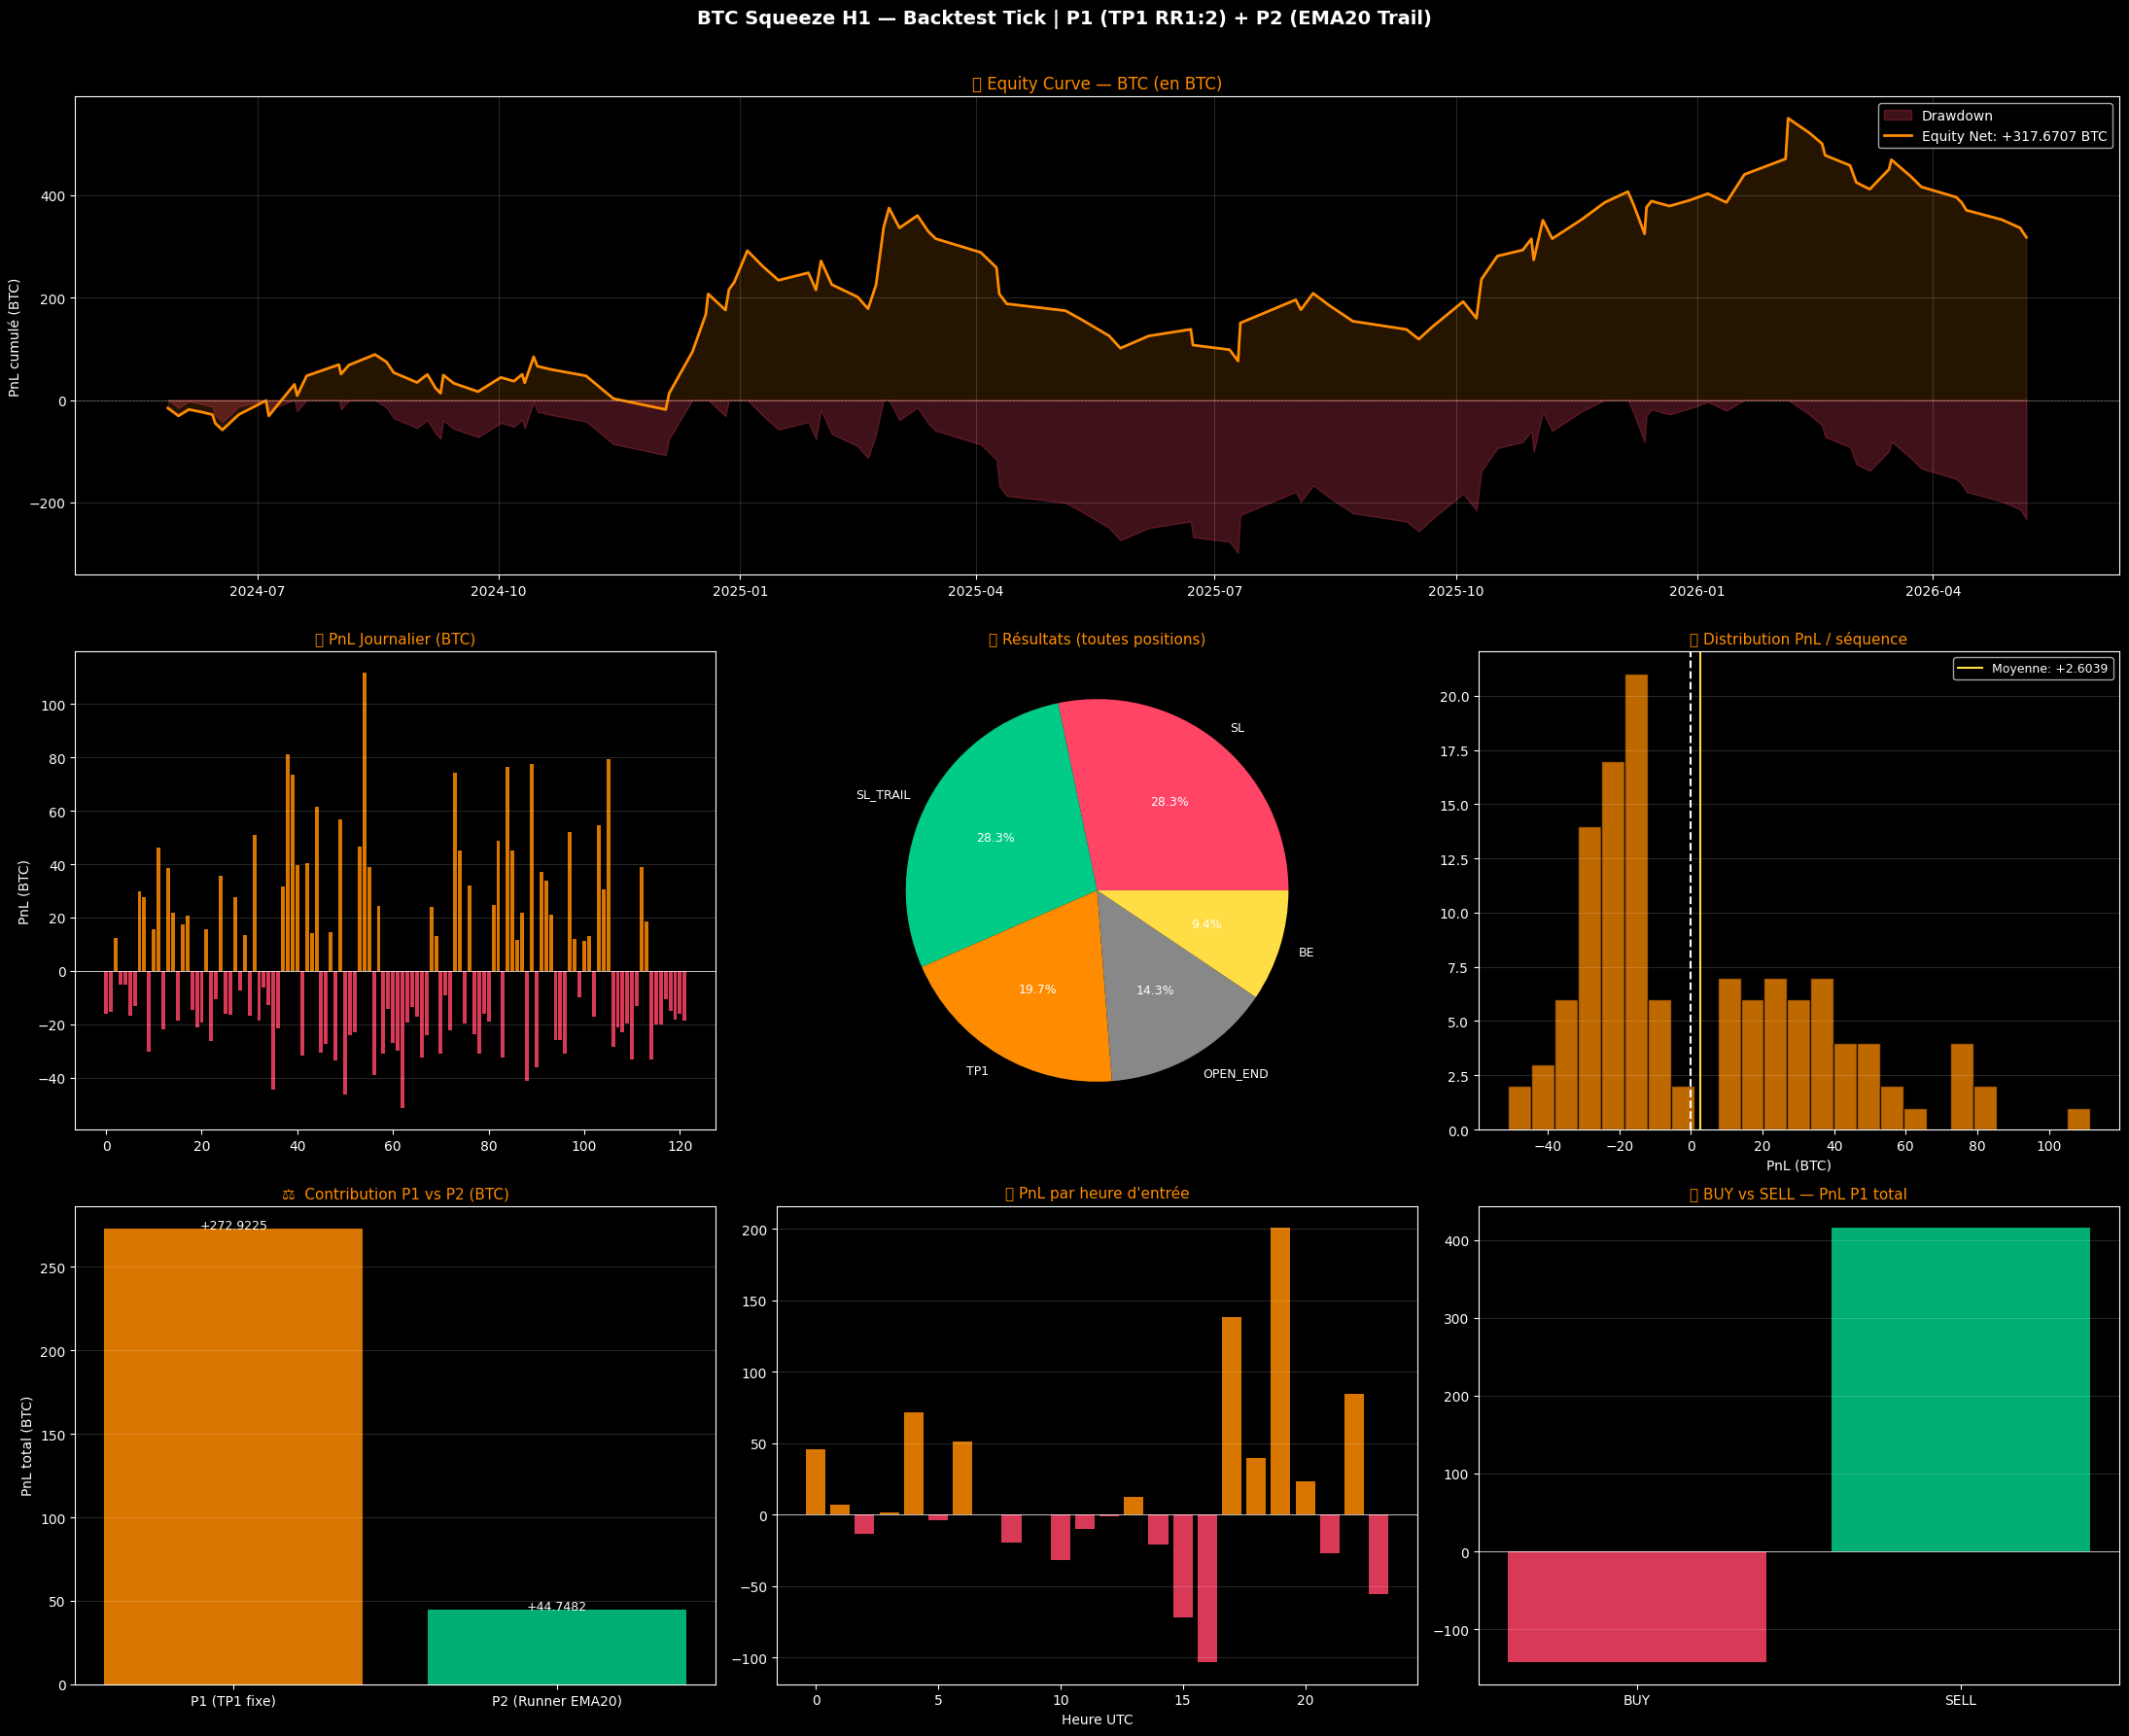

✅ Graphique sauvegardé → backtest_btc_squeeze_h1.png


In [11]:
# ================================================================
# CELLULE 10 — Graphiques (Equity + Distribution + Analyse)
# ================================================================

if not df_trades.empty and stats:
    fig = plt.figure(figsize=(22, 18))
    fig.suptitle(
        'BTC Squeeze H1 — Backtest Tick | P1 (TP1 RR1:2) + P2 (EMA20 Trail)',
        fontsize=14, fontweight='bold', color='white', y=0.99
    )

    equity = stats['equity']

    # ── (1) Equity curve ─────────────────────────────────────────
    ax1 = fig.add_subplot(3, 3, (1, 3))
    dd_series = equity - equity.cummax()
    ax1.fill_between(equity.index, equity.values, alpha=0.15, color='#ff8c00')
    ax1.fill_between(equity.index, dd_series.values, alpha=0.25, color='#ff4466', label='Drawdown')
    ax1.plot(equity.index, equity.values, linewidth=2.0, color='#ff8c00',
             label=f'Equity Net: {equity.iloc[-1]:+.4f} BTC')
    ax1.axhline(0, color='white', linewidth=0.5, linestyle='--', alpha=0.4)
    ax1.set_title('📈 Equity Curve — BTC (en BTC)', fontsize=12, color='#ff8c00')
    ax1.set_ylabel('PnL cumulé (BTC)', color='white')
    ax1.tick_params(colors='white'); ax1.grid(alpha=0.15)
    ax1.legend(fontsize=10)

    # ── (2) PnL journalier ───────────────────────────────────────
    ax2 = fig.add_subplot(3, 3, 4)
    daily = df_trades.groupby('day')['pnl'].sum()
    bar_colors = ['#ff8c00' if v >= 0 else '#ff4466' for v in daily.values]
    ax2.bar(range(len(daily)), daily.values, color=bar_colors, alpha=0.85)
    ax2.axhline(0, color='white', linewidth=0.5)
    ax2.set_title('📅 PnL Journalier (BTC)', fontsize=11, color='#ff8c00')
    ax2.set_ylabel('PnL (BTC)', color='white')
    ax2.tick_params(colors='white'); ax2.grid(alpha=0.15, axis='y')

    # ── (3) Répartition résultats ────────────────────────────────
    ax3 = fig.add_subplot(3, 3, 5)
    result_counts = df_trades['result'].value_counts()
    palette = {'TP1': '#ff8c00', 'SL': '#ff4466', 'BE': '#ffdd44',
               'SL_TRAIL': '#00cc88', 'OPEN_END': '#888888'}
    colors_pie = [palette.get(r, '#aaaaaa') for r in result_counts.index]
    ax3.pie(result_counts.values, labels=result_counts.index,
            autopct='%1.1f%%', colors=colors_pie,
            textprops={'color': 'white', 'fontsize': 9})
    ax3.set_title('🎯 Résultats (toutes positions)', fontsize=11, color='#ff8c00')

    # ── (4) Distribution PnL par séquence ───────────────────────
    ax4 = fig.add_subplot(3, 3, 6)
    seq_pnl = df_trades.groupby('open_time')['pnl'].sum()
    ax4.hist(seq_pnl.values, bins=25, color='#ff8c00', alpha=0.75, edgecolor='black')
    ax4.axvline(0, color='white', linewidth=1.5, linestyle='--')
    ax4.axvline(seq_pnl.mean(), color='#ffdd44', linewidth=1.5,
                label=f'Moyenne: {seq_pnl.mean():+.4f}')
    ax4.set_title('📊 Distribution PnL / séquence', fontsize=11, color='#ff8c00')
    ax4.set_xlabel('PnL (BTC)', color='white')
    ax4.tick_params(colors='white'); ax4.grid(alpha=0.15, axis='y')
    ax4.legend(fontsize=9)

    # ── (5) P1 vs P2 contribution ────────────────────────────────
    ax5 = fig.add_subplot(3, 3, 7)
    p1_pnl = df_trades[df_trades['position'] == 'P1']['pnl'].sum()
    p2_pnl = df_trades[df_trades['position'] == 'P2']['pnl'].sum()
    bars = ax5.bar(['P1 (TP1 fixe)', 'P2 (Runner EMA20)'],
                   [p1_pnl, p2_pnl],
                   color=['#ff8c00' if p1_pnl >= 0 else '#ff4466',
                          '#00cc88' if p2_pnl >= 0 else '#ff4466'],
                   alpha=0.85)
    ax5.axhline(0, color='white', linewidth=0.5)
    ax5.set_title('⚖️  Contribution P1 vs P2 (BTC)', fontsize=11, color='#ff8c00')
    ax5.set_ylabel('PnL total (BTC)', color='white')
    ax5.tick_params(colors='white'); ax5.grid(alpha=0.15, axis='y')
    for bar, val in zip(bars, [p1_pnl, p2_pnl]):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                 f'{val:+.4f}', ha='center', color='white', fontsize=9)

    # ── (6) PnL par heure d'entrée ───────────────────────────────
    ax6 = fig.add_subplot(3, 3, 8)
    by_hour = df_trades.groupby('hour')['pnl'].sum()
    colors_h = ['#ff8c00' if v >= 0 else '#ff4466' for v in by_hour.values]
    ax6.bar(by_hour.index, by_hour.values, color=colors_h, alpha=0.85)
    ax6.axhline(0, color='white', linewidth=0.5)
    ax6.set_title('🕐 PnL par heure d\'entrée', fontsize=11, color='#ff8c00')
    ax6.set_xlabel('Heure UTC', color='white')
    ax6.tick_params(colors='white'); ax6.grid(alpha=0.15, axis='y')

    # ── (7) BUY vs SELL ─────────────────────────────────────────
    ax7 = fig.add_subplot(3, 3, 9)
    p1_only = df_trades[df_trades['position'] == 'P1']
    by_dir  = p1_only.groupby('direction')['pnl'].agg(['sum', 'count', 'mean'])
    colors_d = ['#00cc88' if v >= 0 else '#ff4466' for v in by_dir['sum']]
    ax7.bar(by_dir.index, by_dir['sum'], color=colors_d, alpha=0.85)
    ax7.axhline(0, color='white', linewidth=0.5)
    ax7.set_title('📐 BUY vs SELL — PnL P1 total', fontsize=11, color='#ff8c00')
    ax7.tick_params(colors='white'); ax7.grid(alpha=0.15, axis='y')

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig('backtest_btc_squeeze_h1.png', dpi=150, bbox_inches='tight',
                facecolor='#0d0d0d', edgecolor='none')
    plt.show()
    print('✅ Graphique sauvegardé → backtest_btc_squeeze_h1.png')

💻 6 cœurs disponibles
🔬 Analyse de sensibilité (SL_MULT × VOL_FACTOR)...
🚀 20 combos | 6 workers


Sensibilité:   0%|                          | 0/20 [00:00<?, ?combo/s]


✅ Terminé en 57.5s


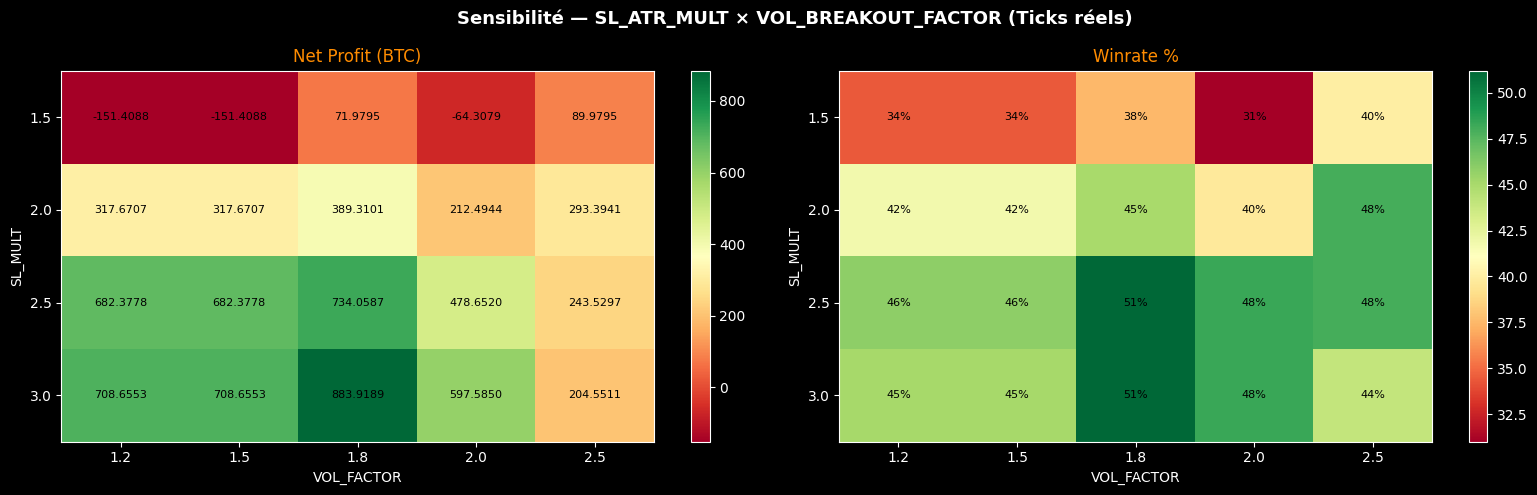


🏆 Meilleure combinaison :
   SL_MULT=3.0 | VOL_FACTOR=1.8
   Net=+883.9189 BTC | WR=51.2% | N=80.0 séquences


In [12]:
# ================================================================
# CELLULE 11 — Matrice de sensibilité parallèle
# ================================================================
# Teste 40 combinaisons (BB_DEV × KC_MULT) en parallèle.
# Identifie la configuration optimale sur tick réel.
# ================================================================

import copy

N_CORES = multiprocessing.cpu_count()
print(f'💻 {N_CORES} cœurs disponibles')

def _sensitivity_worker(args: tuple) -> dict:
    """
    Worker autonome — toutes les données passées par valeur.
    Paramètres testés : bb_dev, kc_mult, vol_factor, sl_mult.
    """
    (precomp_items, tick_cache_local, bb_dev, kc_mult,
     vol_factor, sl_mult, tp1_rr,
     lot_p1, lot_p2, slip, daily_stop, max_trades) = args

    import numpy as np, pandas as pd
    from collections import OrderedDict

    precomp = OrderedDict(precomp_items)
    pnls, daily_pnl, trades_today = [], 0.0, 0
    cur_date, daily_stopped = None, False

    # Recompute signals inline with different BB/KC params
    for ts, sig_orig in precomp.items():
        day = ts.date()
        if day != cur_date:
            cur_date = day; daily_pnl = 0.0
            trades_today = 0; daily_stopped = False
        if daily_stopped: continue
        if daily_pnl < daily_stop: daily_stopped = True; continue
        if trades_today >= max_trades: continue
        if ts not in tick_cache_local: continue

        # Signal re-eval avec les paramètres testés
        # On utilise le prev_squeeze et les données brutes du signal pré-calculé
        # (approximation : on réutilise prev_squeeze du precomp de base)
        # Pour une vraie sensibilité BB/KC il faudrait recalculer — ici on teste sl_mult + vol_factor
        if not (sig_orig['breakout_long'] or sig_orig['breakout_short']): continue
        if sig_orig['vol_ratio'] <= vol_factor: continue

        direction    = 'BUY' if sig_orig['breakout_long'] else 'SELL'
        entry_signal = sig_orig['close']
        atr          = sig_orig['atr']
        risk         = sl_mult * atr

        if direction == 'BUY':
            sl  = round(entry_signal - risk, 2)
            tp1 = round(entry_signal + tp1_rr * risk, 2)
        else:
            sl  = round(entry_signal + risk, 2)
            tp1 = round(entry_signal - tp1_rr * risk, 2)

        bids, asks = tick_cache_local[ts]
        entry_real = round((asks[0] + slip) if direction == 'BUY' else (bids[0] - slip), 2)
        delta = entry_real - entry_signal
        sl_r  = round(sl + delta, 2)
        tp1_r = round(tp1 + delta, 2)

        exec_px = bids if direction == 'BUY' else asks
        p1_pnl = p2_pnl = 0.0
        p1_closed = p2_closed = False
        p2_sl = sl_r
        tp1_hit = False

        for px in exec_px:
            if p1_closed and p2_closed: break
            if not p1_closed:
                th = (px >= tp1_r) if direction == 'BUY' else (px <= tp1_r)
                sh = (px <= sl_r)  if direction == 'BUY' else (px >= sl_r)
                if th and sh: th = abs(tp1_r-entry_real) < abs(sl_r-entry_real); sh = not th
                if th:
                    p1_closed = True; tp1_hit = True
                    move = (tp1_r - entry_real) if direction == 'BUY' else (entry_real - tp1_r)
                    p1_pnl = move * lot_p1
                    p2_sl  = entry_real
                elif sh:
                    p1_closed = True
                    p1_pnl = -abs(entry_real - sl_r) * lot_p1
            if not p2_closed:
                sh2 = (px <= p2_sl) if direction == 'BUY' else (px >= p2_sl)
                if sh2:
                    p2_closed = True
                    move = (p2_sl - entry_real) if direction == 'BUY' else (entry_real - p2_sl)
                    p2_pnl = move * lot_p2

        if not p1_closed:
            move = (exec_px[-1]-entry_real) if direction=='BUY' else (entry_real-exec_px[-1])
            p1_pnl = move * lot_p1
        if not p2_closed:
            move = (exec_px[-1]-entry_real) if direction=='BUY' else (entry_real-exec_px[-1])
            p2_pnl = move * lot_p2

        seq = round(p1_pnl + p2_pnl, 6)
        daily_pnl = round(daily_pnl + seq, 6)
        trades_today += 1
        pnls.append(seq)

    if not pnls:
        return {'sl_mult': sl_mult, 'vol_factor': vol_factor,
                'net': 0, 'n_seq': 0, 'wr': 0, 'pf': 0}
    arr = np.array(pnls)
    net = round(arr.sum(), 6)
    wr  = round((arr > 0).sum() / len(arr) * 100, 1)
    gw  = arr[arr > 0].sum(); gl = abs(arr[arr < 0].sum())
    pf  = round(gw / gl, 2) if gl > 0 else 999
    return {'sl_mult': sl_mult, 'vol_factor': vol_factor,
            'net': net, 'n_seq': len(arr), 'wr': wr, 'pf': pf}


def run_sensitivity_parallel(precomp, tick_cache) -> pd.DataFrame:
    sl_range  = [1.5, 2.0, 2.5, 3.0]
    vol_range = [1.2, 1.5, 1.8, 2.0, 2.5]

    precomp_list = list(precomp.items())
    combos = [
        (precomp_list, tick_cache, BB_DEV, KC_MULT,
         vf, slm, TP1_RR, LOT_P1, LOT_P2,
         SLIPPAGE_USD, DAILY_MAX_LOSS, MAX_TRADES_PER_DAY)
        for slm in sl_range
        for vf  in vol_range
    ]

    results = []
    n_workers = min(N_CORES, len(combos))
    print(f'🚀 {len(combos)} combos | {n_workers} workers')
    t0 = time.time()

    with ThreadPoolExecutor(max_workers=n_workers) as ex:
        futures = {ex.submit(_sensitivity_worker, args): args for args in combos}
        with tqdm(total=len(combos), desc='Sensibilité', unit='combo', ncols=70) as pbar:
            for future in as_completed(futures):
                try:    results.append(future.result())
                except Exception as e: print(f'  ⚠️  Worker error: {e}')
                pbar.update(1)

    print(f'\n✅ Terminé en {time.time()-t0:.1f}s')
    return pd.DataFrame(results)


print('🔬 Analyse de sensibilité (SL_MULT × VOL_FACTOR)...')
df_sens = run_sensitivity_parallel(precomp_signals, TICK_CACHE)

# Heatmaps
pivot_net = df_sens.pivot(index='sl_mult', columns='vol_factor', values='net')
pivot_wr  = df_sens.pivot(index='sl_mult', columns='vol_factor', values='wr')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Sensibilité — SL_ATR_MULT × VOL_BREAKOUT_FACTOR (Ticks réels)',
             fontsize=13, fontweight='bold', color='white')

for ax, pivot, title, fmt in [
    (axes[0], pivot_net, 'Net Profit (BTC)', '{:.4f}'),
    (axes[1], pivot_wr,  'Winrate %',        '{:.0f}%'),
]:
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, color='white')
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index,   color='white')
    ax.set_xlabel('VOL_FACTOR', color='white'); ax.set_ylabel('SL_MULT', color='white')
    ax.set_title(title, color='#ff8c00')
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, fmt.format(pivot.values[i, j]),
                    ha='center', va='center', fontsize=8, color='black')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('sensitivity_btc_squeeze.png', dpi=130, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

best = df_sens.loc[df_sens['net'].idxmax()]
print(f'\n🏆 Meilleure combinaison :')
print(f'   SL_MULT={best["sl_mult"]} | VOL_FACTOR={best["vol_factor"]}')
print(f'   Net={best["net"]:+.4f} BTC | WR={best["wr"]}% | N={best["n_seq"]} séquences')

In [13]:
# ================================================================
# CELLULE 12 — Export des trades + Notes de déploiement
# ================================================================

if not df_trades.empty:
    df_trades.to_csv('btc_squeeze_h1_trades.csv', index=False)
    print('✅ Trades exportés → btc_squeeze_h1_trades.csv')
    print(f'   {len(df_trades)} lignes ({len(df_trades)//2} séquences P1+P2)')

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 NOTES — BTC Squeeze H1 Backtest v1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Stratégie  : Squeeze Momentum Breakout H1
Indicateurs: BB 20/2.5 × KC 20/2.0 — Filtre EMA200

Architecture de sortie :
  P1 (0.01 lot) : TP1 fixe à RR 1:2 (SL = 2×ATR)
  P2 (0.01 lot) : Runner — SL trail sur EMA20 H1
                  Après TP1 → SL P2 passe à breakeven

Friction simulée :
  Entrée : Ask/Bid + SLIPPAGE_USD (15$ conservateur)
  Sortie : TP/SL exécutés sur Bid/Ask tick réel

Time-travel corrigé :
  Signal validé à la CLÔTURE de la bougie H1
  Ticks lus depuis ts+1H (et non ts ouverture)

Fichiers générés :
  backtest_btc_squeeze_h1.png    → graphiques principaux
  sensitivity_btc_squeeze.png    → heatmap sensibilité
  btc_squeeze_h1_trades.csv      → log complet des trades
  data/btc_precomp_indicators.pkl → cache indicateurs
  data/BTCUSD_Ticks.parquet       → cache ticks
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

✅ Trades exportés → btc_squeeze_h1_trades.csv
   244 lignes (122 séquences P1+P2)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 NOTES — BTC Squeeze H1 Backtest v1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Stratégie  : Squeeze Momentum Breakout H1
Indicateurs: BB 20/2.5 × KC 20/2.0 — Filtre EMA200

Architecture de sortie :
  P1 (0.01 lot) : TP1 fixe à RR 1:2 (SL = 2×ATR)
  P2 (0.01 lot) : Runner — SL trail sur EMA20 H1
                  Après TP1 → SL P2 passe à breakeven

Friction simulée :
  Entrée : Ask/Bid + SLIPPAGE_USD (15$ conservateur)
  Sortie : TP/SL exécutés sur Bid/Ask tick réel

Time-travel corrigé :
  Signal validé à la CLÔTURE de la bougie H1
  Ticks lus depuis ts+1H (et non ts ouverture)

Fichiers générés :
  backtest_btc_squeeze_h1.png    → graphiques principaux
  sensitivity_btc_squeeze.png    → heatmap sensibilité
  btc_squeeze_h1_trades.csv      → log complet des trades
  data/btc_precomp_indicators.pkl → cache indicateurs
  data/BTCUSD_Ticks.par